In [22]:
%load_ext autoreload
%autoreload 2
import icechunk
import matplotlib.pyplot as plt
import zarr

from srm import catalog
from srm.downscaling_utils import interpolate_fine_to_coarse_grid, rechunk
from srm.qaqc import (
    disagg_test_calculate_metrics,
)
import xarray as xr
from srm.utils import open_icechunk

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Get data

In [3]:
path_output = (
    "s3://carbonplan-srm/output/production/CESM2-WACCM-ERA5-global.icechunk"
)
var = "DTR"
scenario = "historical"
ens = "r3i1p1f1"
branch = "v0.11.0"

In [4]:
storage = icechunk.s3_storage(
    bucket="carbonplan-srm",  # "carbonplan-srm",
    # prefix="srm/output/qa/CESM2-WACCM-ERA5-lat-35.0to-22.0_lon16.0to33.0.icechunk/",
    prefix="output/production/CESM2-WACCM-ERA5-global.icechunk/",
    region="us-west-2")
repo = icechunk.Repository.open(storage)
print(repo.list_branches())
session = repo.readonly_session(branch=branch)
root = zarr.open_group(session.store, mode="r")
print(root.tree())

{'v0.11.0', 'main', 'v0.10.0', 'v0.7.0', 'v0.8.0'}
/
├── debiased_coarse
│   ├── g6_1p5k
│   │   ├── dtr
│   │   │   └── 003
│   │   │       ├── dtr (25568, 192, 288) float32
│   │   │       ├── lat (192,) float64
│   │   │       ├── lon (288,) float64
│   │   │       └── time (25568,) int64
│   │   ├── hurs
│   │   │   └── 003
│   │   │       ├── hurs (25568, 192, 288) float32
│   │   │       ├── lat (192,) float64
│   │   │       ├── lon (288,) float64
│   │   │       └── time (25568,) int64
│   │   ├── pr
│   │   │   └── 003
│   │   │       ├── lat (192,) float64
│   │   │       ├── lon (288,) float64
│   │   │       ├── pr (25568, 192, 288) float32
│   │   │       └── time (25568,) int64
│   │   ├── rsds
│   │   │   └── 003
│   │   │       ├── lat (192,) float64
│   │   │       ├── lon (288,) float64
│   │   │       ├── rsds (25568, 192, 288) float32
│   │   │       └── time (25568,) int64
│   │   ├── tas
│   │   │   └── 003
│   │   │       ├── lat (192,) float64
│   │   │       ├─

In [5]:
obs = catalog.get("ERA5").to_xarray()

In [5]:
dtr = (obs.tasmax - obs.tasmin).compute()

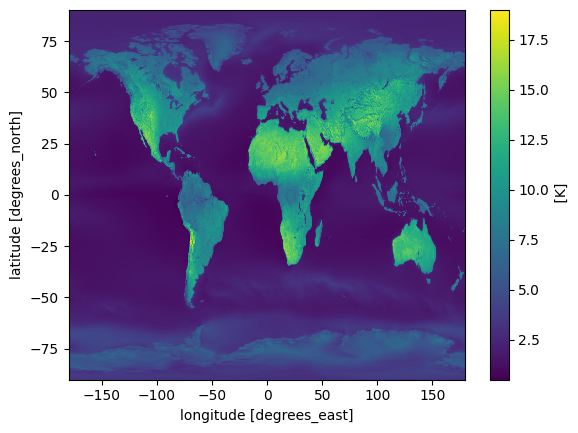

In [7]:
dtr.mean(dim='time').plot()

In [11]:
small_dtr = (dtr<1).sum(dim='time').compute()

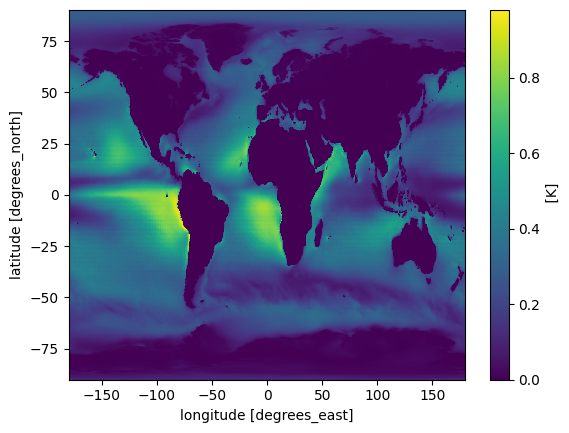

In [13]:
(small_dtr/len(dtr.time.values)).plot()

In [6]:
# subset to region to help with compute - quantile takes a lot!

In [7]:
lat_slice = slice(25, 60)
lon_slice = slice(-125, -70)

In [12]:
obs = obs.sel(lat=lat_slice, lon=lon_slice)
dtr = (obs.tasmax - obs.tasmin).compute()

In [14]:
dtr_q1 = dtr.quantile(0.1, dim='time', skipna=True).compute()

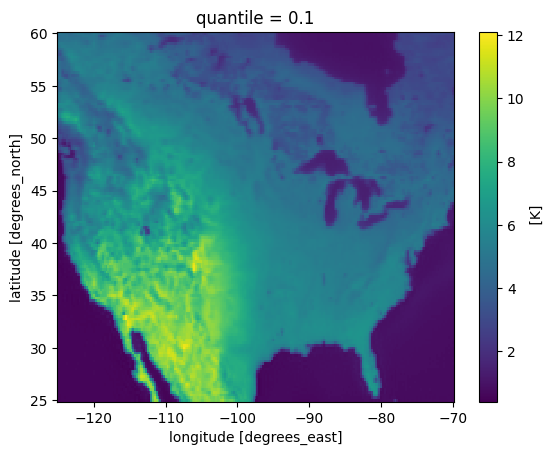

In [16]:
dtr_q1.plot()

# inspecting single location in north america

In [17]:
lat = 38
lon = -90

In [ ]:
ens_dict = {'historical': {'tas': 'r3i1p1f1',
                           'tasmax': '001',
                           'tasmin': '001'},
            'g6_1p5k': {'tas': '003',
                        'tasmax': '003',
                        'tasmin': '003'}}

In [81]:
scenario='historical'
downscaled = xr.Dataset()

for var, ens in ens_dict[scenario].items():
    downscaled[var] = open_icechunk(
        path=path_output,
        branch=branch,
        group=scenario + "/" + var + "/" + ens,
    )[var]
downscaled = downscaled.sel(lat=lat, lon=lon)


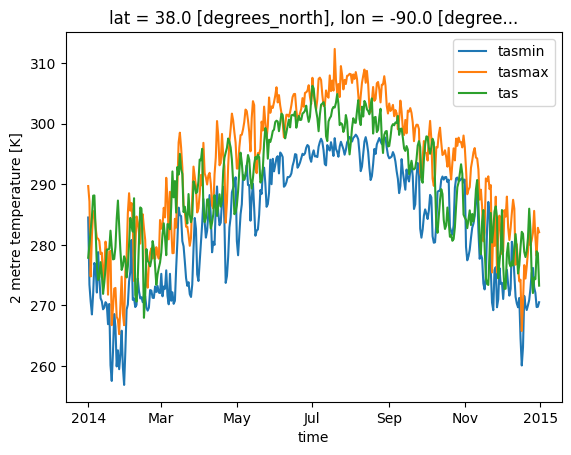

In [82]:
fig, ax = plt.subplots()
year = '2014'
downscaled.sel(time=slice(year, year)).tasmin.plot(ax=ax, label='tasmin')
downscaled.sel(time=slice(year, year)).tasmax.plot(ax=ax, label='tasmax')
downscaled.sel(time=slice(year, year)).tas.plot(ax=ax, label='tas')

plt.legend()

In [83]:
(downscaled.tasmin > downscaled.tas).sum().values/len((downscaled.tasmin.time))

np.float64(0.23405357407133343)

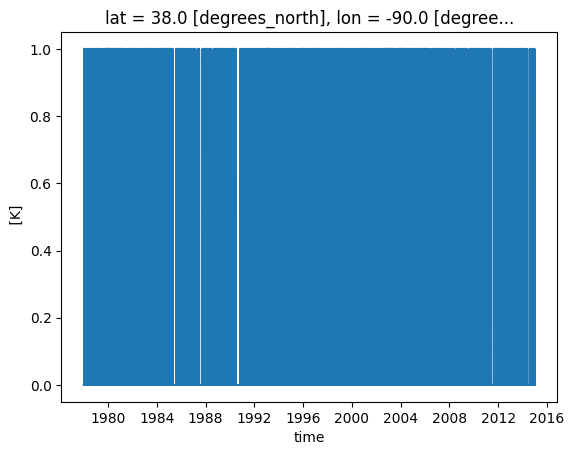

In [84]:
(downscaled.tasmin > downscaled.tas).plot()

In [86]:
scenario='g6_1p5k'
downscaled = xr.Dataset()

for var, ens in ens_dict[scenario].items():
    downscaled[var] = open_icechunk(
        path=path_output,
        branch=branch,
        group=scenario + "/" + var + "/" + ens,
    )[var]
downscaled = downscaled.sel(lat=lat, lon=lon)


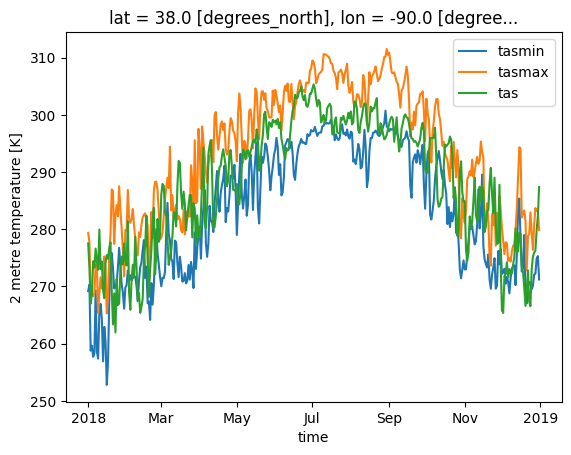

In [87]:
fig, ax = plt.subplots()
year = '2018'
downscaled.sel(time=slice(year, year)).tasmin.plot(ax=ax, label='tasmin')
downscaled.sel(time=slice(year, year)).tasmax.plot(ax=ax, label='tasmax')
downscaled.sel(time=slice(year, year)).tas.plot(ax=ax, label='tas')

plt.legend()

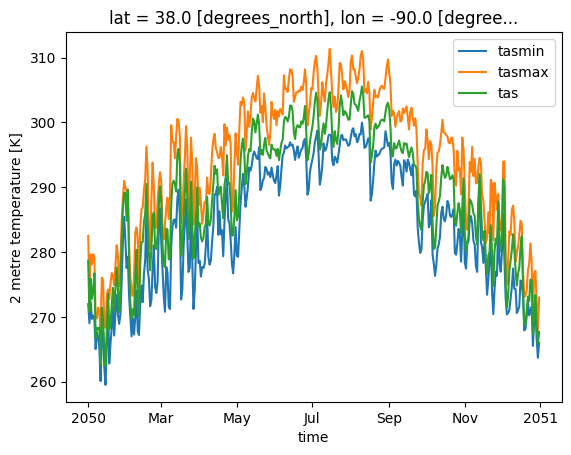

In [75]:
fig, ax = plt.subplots()
year = '2050'
downscaled.sel(time=slice(year, year)).tasmin.plot(ax=ax, label='tasmin')
downscaled.sel(time=slice(year, year)).tasmax.plot(ax=ax, label='tasmax')
downscaled.sel(time=slice(year, year)).tas.plot(ax=ax, label='tas')

plt.legend()

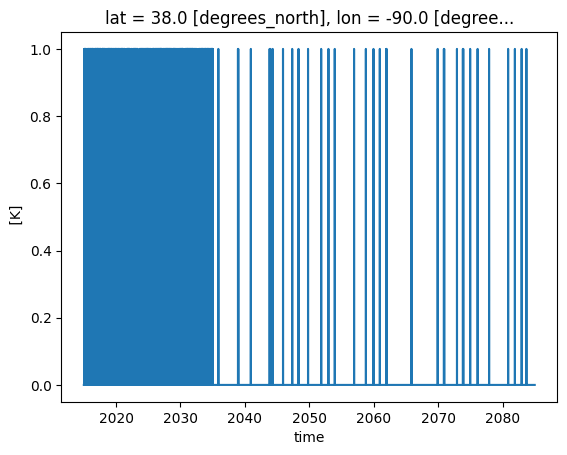

In [76]:
(downscaled.tasmin > downscaled.tas).plot()

In [77]:
(downscaled.tasmin > downscaled.tas).sum().values/len((downscaled.tasmin.time))

np.float64(0.06367334167709637)

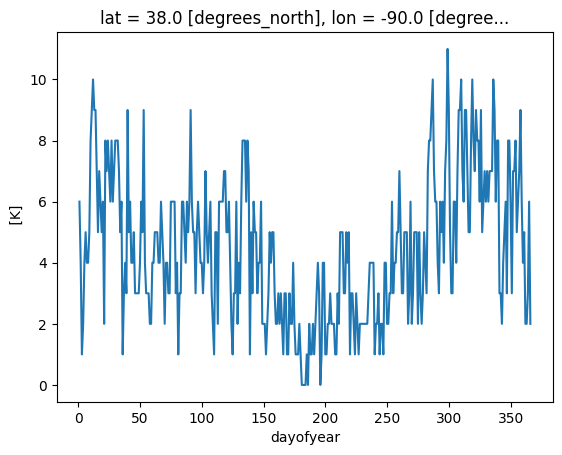

In [78]:
(downscaled.tasmin > downscaled.tas).groupby('time.dayofyear').sum().plot()

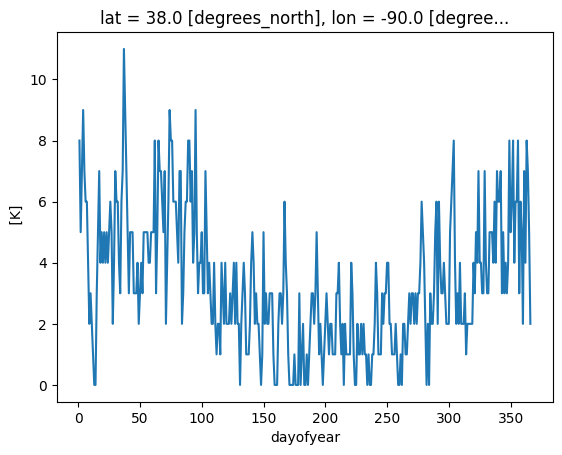

In [79]:
(downscaled.tasmax < downscaled.tas).groupby('time.dayofyear').sum().plot()

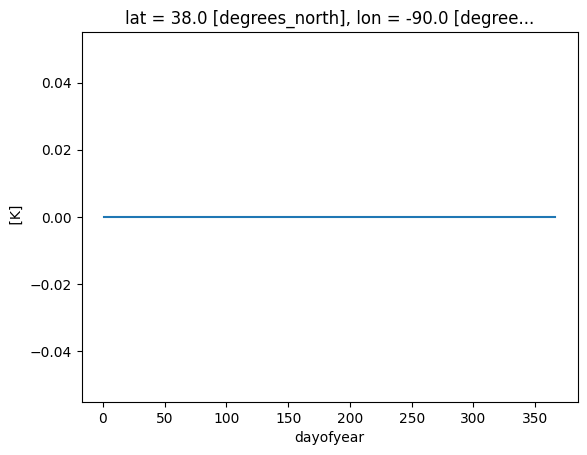

In [88]:
(downscaled.tasmax < downscaled.tasmin).groupby('time.dayofyear').sum().plot()